# Quantitative Risk Assessment - Indicators & Warning (I&W) + Monte Carlo
## Pfizer Inc. / Seagen Acquisition | Group 10 | Module 3

Quantitative layer applied on top of the qualitative Module 2 Risk Assessment. Three priority competitive risks are assessed with the **Indicators & Warning (I&W)** technique; indicator readings inform **probability** distributions and **Monte Carlo simulation** propagates impact uncertainty into expected-loss/value distributions, a risk matrix, and loss-exceedance curves.

**Risks:** R-MSE ADC market-share erosion (threat), R-006 critical ADC talent poaching (threat), R-010 first-mover ADC combination advantage (opportunity).

**Data sources** - model inputs are defined inline (Section 1); the link-shared Drive files `riskregister.csv` and `Monte Carlo Results` are loaded as optional reference (Sections 1b, 4).

**Reproduce:** run all cells in Colab/Jupyter (`pip install numpy pandas scipy matplotlib` if local). Seed fixed (42).

### 1. Model inputs (I&W parameters)
Triangular probability range (min/mode/max) per risk from I&W indicator readings, and triangular impact range (\$B) anchored to the Group 10 DCF model and register figures.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

rng = np.random.default_rng(42)
N = 100_000
colors = {'R-MSE':'#C0392B','R-006':'#E67E22','R-010':'#27AE60'}

# --- I&W parameters (triangular probability and impact distributions) ---
inp = pd.DataFrame([
    {'risk_id':'R-MSE','risk_name':'ADC market-share erosion','risk_type':'Threat',
     'p_min':0.30,'p_mode':0.55,'p_max':0.75,'impact_min_Bn':1.00,'impact_mode_Bn':4.42,'impact_max_Bn':9.57},
    {'risk_id':'R-006','risk_name':'Critical ADC talent poaching','risk_type':'Threat',
     'p_min':0.35,'p_mode':0.55,'p_max':0.75,'impact_min_Bn':0.20,'impact_mode_Bn':0.60,'impact_max_Bn':1.20},
    {'risk_id':'R-010','risk_name':'First-mover ADC combination advantage','risk_type':'Opportunity',
     'p_min':0.30,'p_mode':0.50,'p_max':0.70,'impact_min_Bn':1.00,'impact_mode_Bn':1.50,'impact_max_Bn':2.50},
])
print(inp.to_string(index=False))

risk_id                             risk_name   risk_type  p_min  p_mode  p_max  impact_min_Bn  impact_mode_Bn  impact_max_Bn
  R-MSE              ADC market-share erosion      Threat   0.30    0.55   0.75            1.0            4.42           9.57
  R-006          Critical ADC talent poaching      Threat   0.35    0.55   0.75            0.2            0.60           1.20
  R-010 First-mover ADC combination advantage Opportunity   0.30    0.50   0.70            1.0            1.50           2.50


### 1b. (Optional) Load reference files from Google Drive
Not required for the simulation. Wrapped in `try/except` so a private file or unexpected schema prints a note instead of stopping the notebook. Files must be shared as *Anyone with the link - Viewer*.

In [2]:
REGISTER_ID = '1g0teLbHuWSV9YBP8Oj6My0FD0MuWbPzJ'  # riskregister.csv
RESULTS_ID  = '1K4YNmV1ci6fXzHb_KFj7zhmXNCTyZGuk'  # Monte Carlo Results

def load_drive_csv(file_id):
    return pd.read_csv(f'https://drive.google.com/uc?export=download&id={file_id}')

try:
    register_df = load_drive_csv(REGISTER_ID)
    print('riskregister.csv:', register_df.shape[0], 'rows x', register_df.shape[1], 'cols')
    display(register_df.head())
except Exception as e:
    print(f'[info] riskregister.csv not loaded: {type(e).__name__}: {e}')

### 2. Monte Carlo engine
Each iteration draws `p ~ Triangular` and `I ~ Triangular`; expected loss/value `EL = p x I`. A Bernoulli occurrence gives a scenario (loss-exceedance) view for P90 value-at-risk. 100,000 iterations per risk. Full arrays are retained for the visualizations.

In [3]:
def tri(a,m,b): return rng.triangular(a,m,b,N)

rows, S = [], {}
for _, r in inp.iterrows():
    p   = tri(r.p_min, r.p_mode, r.p_max)
    imp = tri(r.impact_min_Bn, r.impact_mode_Bn, r.impact_max_Bn)
    el  = p * imp
    scen = np.where(rng.random(N) < p, imp, 0.0)
    S[r.risk_id] = {'name':r.risk_name,'type':r.risk_type,'el':el,'imp':imp,'scen':scen,
                    'pmean':p.mean(),'i50':np.percentile(imp,50),'i90':np.percentile(imp,90),
                    'elmean':el.mean(),'el50':np.percentile(el,50),'el90':np.percentile(el,90),
                    'var90':np.percentile(scen,90)}
    rows.append({'Risk ID':r.risk_id,'Risk':r.risk_name,'Type':r.risk_type,
        'Mean Probability':round(p.mean(),3),'Impact P50 ($B)':round(np.percentile(imp,50),2),
        'Impact P90 ($B)':round(np.percentile(imp,90),2),
        'Expected Loss/Value mean ($B)':round(el.mean(),2),
        'EL P90 ($B)':round(np.percentile(el,90),2),
        'Scenario VaR P90 ($B)':round(np.percentile(scen,90),2)})

res = pd.DataFrame(rows); res.to_csv('iw_montecarlo_results.csv', index=False)
print(res.to_string(index=False))

Risk ID                                  Risk        Type  Mean Probability  Impact P50 ($B)  Impact P90 ($B)  Expected Loss/Value mean ($B)  EL P50 ($B)  EL P90 ($B)  Scenario VaR P90 ($B)  Quant Likelihood (1-10)
  R-MSE              ADC market-share erosion      Threat             0.533             4.86             7.48                           2.66         2.55         4.13                   6.67                        5
  R-006          Critical ADC talent poaching      Threat             0.550             0.65             0.95                           0.37         0.35         0.54                   0.87                        5
  R-010 First-mover ADC combination advantage Opportunity             0.500             1.64             2.11                           0.83         0.81         1.12                   1.95                        5


### 3. Visualizations
Four views of the quantitative results: (3.1) the expected loss/value distributions, (3.2) a quantitative risk matrix, (3.3) expected loss/value ranking with P50-P90 spread, and (3.4) loss/value exceedance curves.

**3.1 Expected loss/value distributions** - threats are losses (red/orange); the opportunity is upside (green).

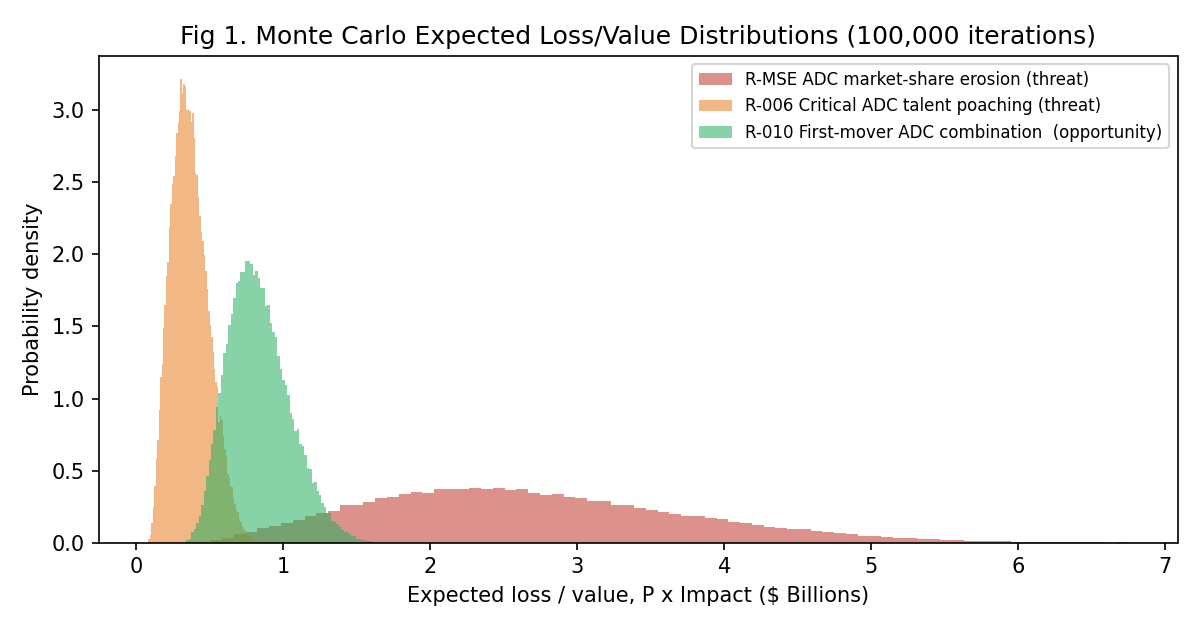

In [4]:
fig, ax = plt.subplots(figsize=(8,4.2))
for rid in S:
    ax.hist(S[rid]['el'], bins=80, density=True, alpha=0.55, color=colors[rid],
            label=f"{rid} {S[rid]['name'][:28]} ({S[rid]['type'].lower()})")
ax.set_xlabel('Expected loss / value, P x Impact ($ Billions)'); ax.set_ylabel('Probability density')
ax.set_title('Fig 1. Monte Carlo Expected Loss/Value Distributions (100,000 iterations)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

**3.2 Quantitative risk matrix** - mean probability vs. P50 impact; bubble area is proportional to expected loss/value. The shaded zone marks high-probability, high-impact exposure.

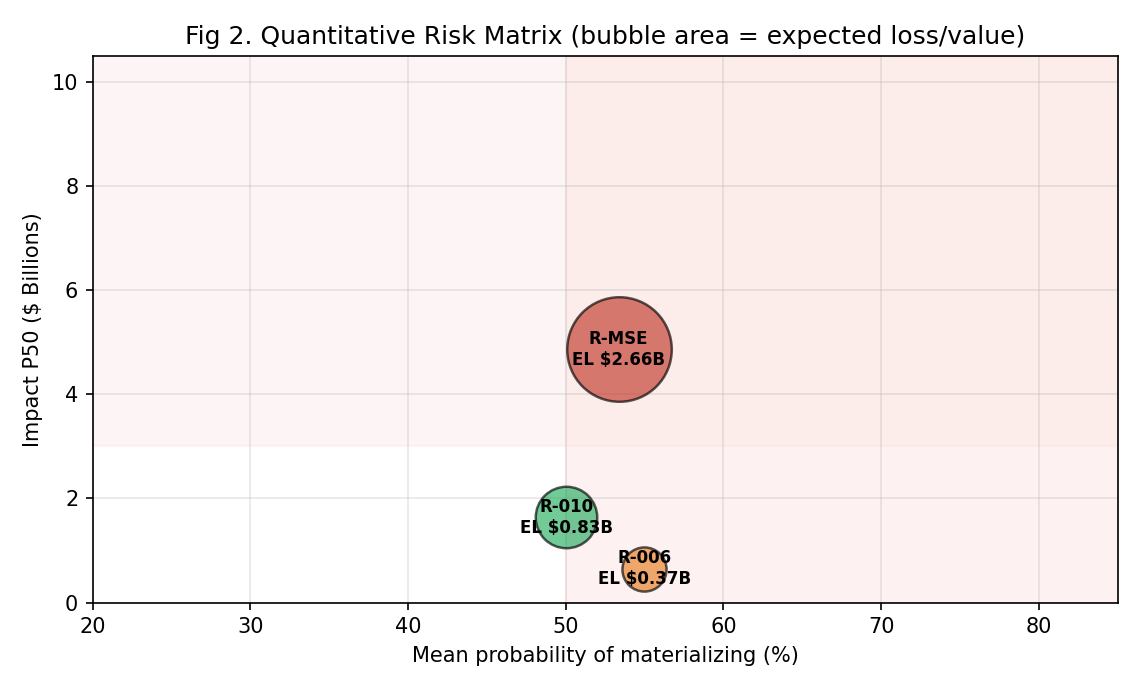

In [5]:
fig, ax = plt.subplots(figsize=(7.6,4.6))
for rid in S:
    d = S[rid]
    ax.scatter(d['pmean']*100, d['i50'], s=abs(d['elmean'])*900+120, color=colors[rid],
               alpha=0.65, edgecolor='black', linewidth=1.2, zorder=3)
    ax.annotate(f"{rid}\nEL ${d['elmean']:.2f}B", (d['pmean']*100, d['i50']),
                ha='center', va='center', fontsize=8, fontweight='bold', zorder=4)
ax.axvspan(50,100,color='#FADBD8',alpha=0.35,zorder=0); ax.axhspan(3,11,color='#FADBD8',alpha=0.25,zorder=0)
ax.set_xlim(20,85); ax.set_ylim(0,10.5)
ax.set_xlabel('Mean probability of materializing (%)'); ax.set_ylabel('Impact P50 ($ Billions)')
ax.set_title('Fig 2. Quantitative Risk Matrix (bubble area = expected loss/value)')
ax.grid(alpha=0.3, zorder=1); plt.tight_layout(); plt.show()

**3.3 Expected loss/value by risk** - bars are the mean; whiskers span EL P50 to P90 (parameter uncertainty).

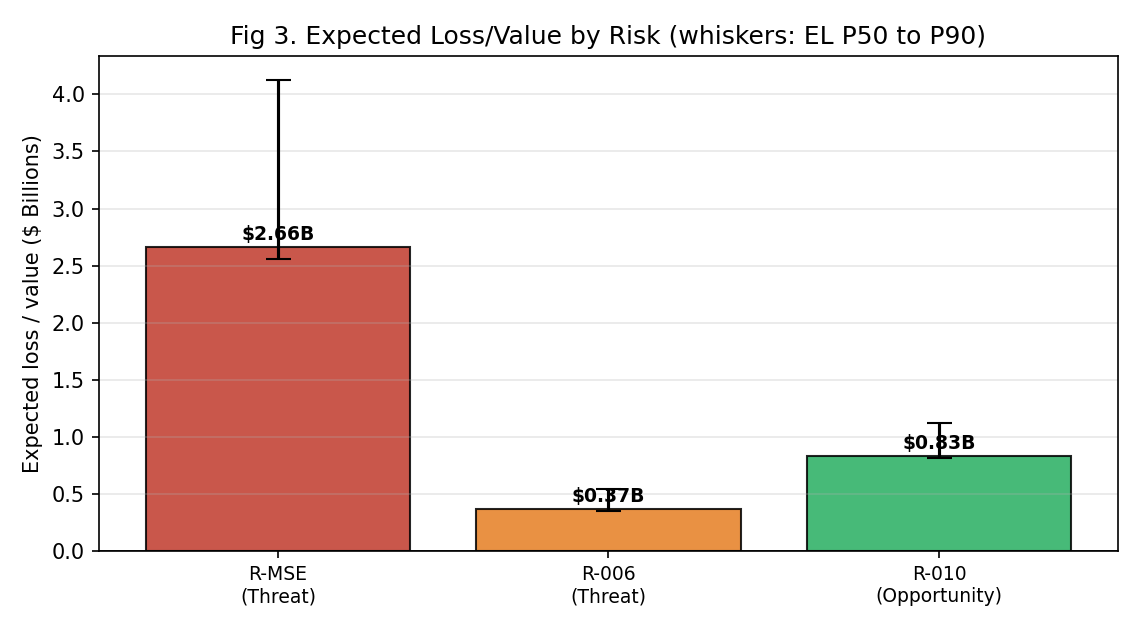

In [6]:
fig, ax = plt.subplots(figsize=(7.6,4.2))
ids = list(S.keys()); x = np.arange(len(ids))
means = [S[r]['elmean'] for r in ids]
lo = [abs(S[r]['elmean']-S[r]['el50']) for r in ids]; hi = [abs(S[r]['el90']-S[r]['elmean']) for r in ids]
ax.bar(x, means, color=[colors[r] for r in ids], alpha=0.85, yerr=[lo,hi], capsize=6, edgecolor='black')
for xi,r in zip(x,ids): ax.text(xi, S[r]['elmean']+0.06, f"${S[r]['elmean']:.2f}B", ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f"{r}\n({S[r]['type']})" for r in ids], fontsize=9)
ax.set_ylabel('Expected loss / value ($ Billions)')
ax.set_title('Fig 3. Expected Loss/Value by Risk (whiskers: EL P50 to P90)')
ax.axhline(0,color='black',linewidth=0.8); ax.grid(axis='y',alpha=0.3); plt.tight_layout(); plt.show()

**3.4 Loss/value exceedance curves** - for each risk, the probability that the scenario outcome exceeds a given threshold; the P90 point is the scenario value-at-risk.

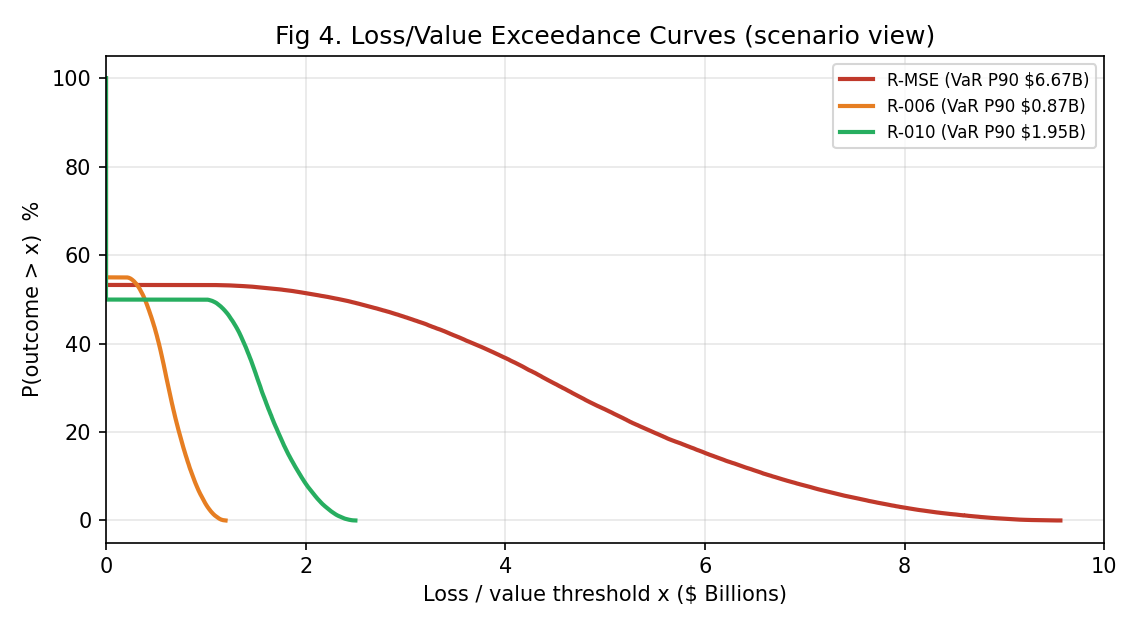

In [7]:
fig, ax = plt.subplots(figsize=(7.6,4.2))
for rid in S:
    d = S[rid]; xs = np.sort(d['scen']); exc = 1.0 - np.arange(len(xs))/len(xs)
    ax.plot(xs, exc*100, color=colors[rid], linewidth=2, label=f"{rid} (VaR P90 ${d['var90']:.2f}B)")
ax.set_xlabel('Loss / value threshold x ($ Billions)'); ax.set_ylabel('P(outcome > x)  %')
ax.set_title('Fig 4. Loss/Value Exceedance Curves (scenario view)')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xlim(0,10); plt.tight_layout(); plt.show()

### 4. High-level results and verification against the published Drive copy
The probability, impact P50/P90, and expected loss/value above feed the updated Risk Register (Quant I&W Assessment tab). The optional cell below loads the published `Monte Carlo Results` from Google Drive to confirm the figures match.

**ML note:** probability inputs can be refined with a supervised classifier (logistic regression / gradient boosting) trained on historical biopharma M&A integration outcomes using the same I&W indicators as features; Monte Carlo then propagates the impact uncertainty around that estimate.

In [8]:
try:
    published = load_drive_csv(RESULTS_ID)
    print('Published Monte Carlo Results (Google Drive):'); display(published)
except Exception as e:
    print(f'[info] Monte Carlo Results not loaded: {type(e).__name__}: {e}')